### Multimodel-Rag with langchain

### Setup

#### Install the dependencies you need to run the notebook.

In [1]:
# %pip install -Uq "unstructured[all-docs]" pillow lxml pillow
# %pip install -Uq chromadb tiktoken
# %pip install -Uq python_dotenv
# %pip install -Uq langchain langchain-community langchain-openai langchain-groq

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

### Extract the data

In [2]:
from unstructured.partition.pdf import partition_pdf

output_path = "./content/"
file_path = output_path + "attention.pdf"

print(file_path)

./content/attention.pdf


In [4]:
from unstructured.partition.pdf import partition_pdf  # Import partition_pdf for PDF extraction

output_path = "./content/"                            # Folder containing the PDF
file_path = output_path + "attention.pdf"             # Full path of the PDF file

chunks = partition_pdf(                               # Extract and chunk the PDF
    filename=file_path,                                # PDF file to process

    infer_table_structure=True,                        # Detect and extract table structure
    strategy="hi_res",                                 # Use high-resolution PDF analysis

    extract_image_block_types=["Image"],               # Extract Image elements from the PDF
    extract_image_block_to_payload=True,               # Store image data as Base64 in the element

    chunking_strategy="by_title",                      # Split content based on titles/sections
    max_characters=10000,                               # Maximum characters allowed in one chunk
    combine_text_under_n_chars=2000,                   # Combine small text pieces below 2000 characters
    new_after_n_chars=6000                              # Try to start a new chunk around 6000 characters
)

No languages specified, defaulting to English.


Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [43]:
len(chunks)

18

In [45]:
#Checks what types of elements were extracted from the PDF.
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [46]:
chunks[0].to_dict()

{'type': 'CompositeElement',
 'element_id': 'db238a709d4b353d9c097e2c90fc5efb',
 'text': '3\n\n2023\n\n2\n\n0\n\n2\n\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0 7\n\n1\n\n:\n\nv\n\narXiv\n\ni\n\nX\n\nr\n\na\n\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\nAttention Is All You Need\n\nAshish Vaswani∗\n\nGoogle Brain\n\navaswani@google.com\n\nNoam Shazeer∗\n\nGoogle Brain noam@google.com\n\nNiki Parmar∗\n\nGoogle Research nikip@google.com\n\nJakob Uszkoreit∗\n\nGoogle Research usz@google.com\n\nLlion Jones∗\n\nGoogle Research llion@google.com\n\nAidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu\n\nŁukasz Kaiser∗ Google Brain lukaszkaiser@google.com\n\nIllia Polosukhin∗ ‡\n\nillia.polosukhin@gmail.com\n\nAbstract\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a 

In [8]:
# Get the original elements that were combined
# to create the first CompositeElement chunk.
chunks[0].metadata.orig_elements

In [9]:
## Extract Image from Chunk
elements = chunks[0].metadata.orig_elements # Gets the original elements from the first chunk
chunk_images = [el for el in elements if "Image" in str(type(el))] # Filters and stores only the Image elements.
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': '14944f74-3ea9-4d6e-b5f2-bb52b14438cc',
 'text': 'Output Probabilities Add & Norm Feed Forward Add & Norm Multi-Head Attention a, Add & Norm Nx Add & Norm Feed Forward Nx | —-Casda Nom] Add & Norm VWEeea Multi-Head Multi-Head Attention Attention Sy ae, SE a, Positional CY Encoding ® Positional @ q Encoding Input Embedding Inputs Outputs (shifted right) Output Embedding',
 'metadata': {'coordinates': {'points': ((np.float64(955.4951388888888),
     np.float64(350.00972222222197)),
    (np.float64(955.4951388888888), np.float64(1917.309722222222)),
    (np.float64(2019.4951388888885), np.float64(1917.309722222222)),
    (np.float64(2019.4951388888885), np.float64(350.00972222222197))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-09-11T14:16:24',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 3,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extract elements into tables, text, and images

In [5]:
# Seperate tables from text
tables = []
text = []
for chunk in chunks:
    if "Table" in str(type((chunk))):
        tables.append(chunk) 
    if "CompositeElement" in str(type((chunk))):
        text.append(chunk)

In [6]:
##Get the images from the CompoisteElement Object

def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)

    return images_b64

In [7]:
images = get_images_base64(chunks) 
len(images)

7

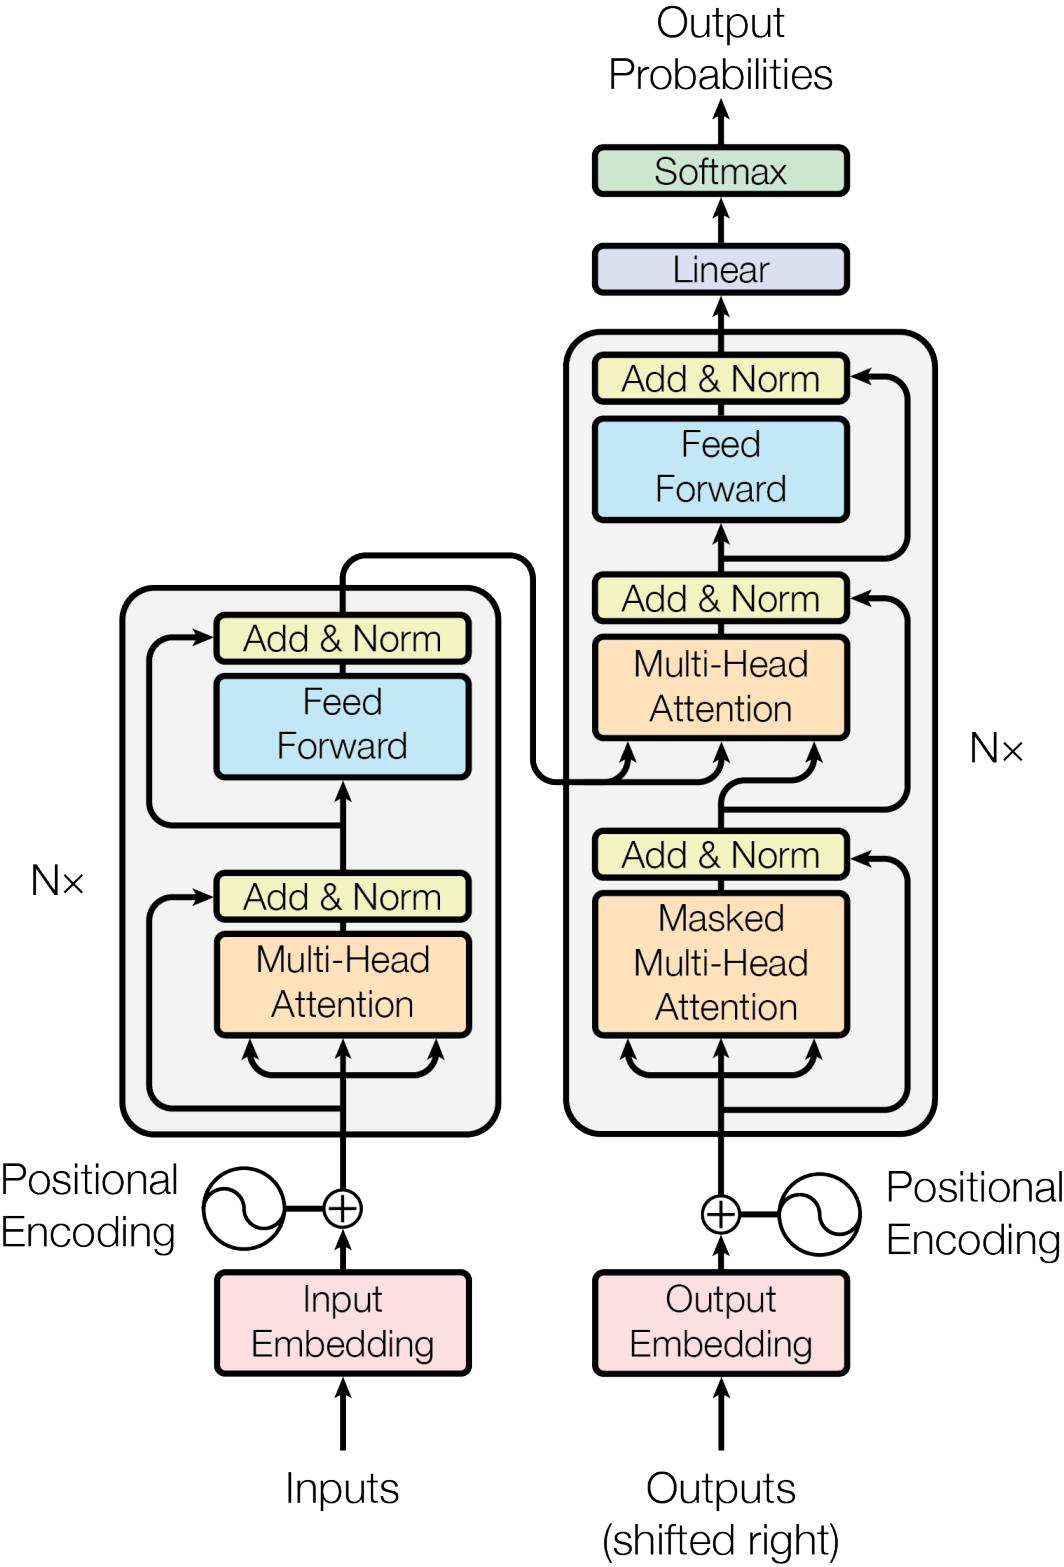

In [8]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    image_data = base64.b64decode(base64_code)
    display(Image(data=image_data))
display_base64_image(images[0])

### Summarize the data

#### creat a summary of each element extract from the PDF. This summary will be vectorized and used in the retrieval process

### Text and Table Summary

In [10]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


In [11]:
## Prompt

prompt_text = """You are an assistant with tasked with the summarizing tables and texts.
Give a concise summary of the table or text.

Response only with the summary, no additional command.
Do not start your message saying "Here is a summary" or anything like that
Just give the summary as it is.
Table or text chunk: {element}
"""

prompt = ChatPromptTemplate.from_template(prompt_text)

## summary chain
model = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0,
    max_tokens=400,
    reasoning_effort="none"
)

final_chain=(
    prompt 
    | model
    | StrOutputParser()
)

In [14]:
## Summarize text

text_summarize = final_chain.batch(
    text,
    {"max_concurrency": 1}
)


## Summarize tables

table_html = [
    table.metadata.text_as_html
    for table in tables
]

summarize_table = final_chain.batch(
    table_html,
    {"max_concurrency": 1}
)

In [29]:
text_summarize 

['The provided text is the introduction and methodology section of the seminal paper "Attention Is All You Need," which introduces the Transformer, a novel sequence transduction architecture that relies entirely on attention mechanisms, eliminating the need for recurrence or convolutions. The authors demonstrate that the Transformer achieves superior quality and significantly faster training times compared to recurrent and convolutional models, setting new state-of-the-art BLEU scores on WMT 2014 English-to-German and English-to-French translation tasks. The paper details the model\'s encoder-decoder structure, composed of stacked self-attention and feed-forward layers with residual connections and layer normalization, and explains the core components of scaled dot-product and multi-head attention.',
 "The text details the Transformer model's core components: Scaled Dot-Product Attention, which scales dot products to prevent softmax saturation; Multi-Head Attention, which projects quer

In [30]:
summarize_table

['The table compares Self-Attention, Recurrent, Convolutional, and Restricted Self-Attention layers, showing that Self-Attention and Convolutional layers offer O(1) sequential operations and short path lengths, whereas Recurrent layers require O(n) sequential operations and have O(n) path lengths.',
 'The table compares the performance of various machine translation models, including ByteNet, GNMT, ConvS2S, MoE, and Transformer variants, on English-to-German (EN-DE) and English-to-French (EN-FR) tasks using BLEU scores. It also details the training and inference computational costs in FLOPs. The Transformer (big) model achieves the highest BLEU scores (28.4 for EN-DE and 41.8 for EN-FR) among the listed models, while ensemble methods generally outperform their single-model counterparts.',
 'The table compares the performance of various Transformer model configurations (base, A–E, and big) based on architectural parameters such as number of layers (N), model dimension (d_model), hidden 

### Image summaries

In [15]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


# Image description prompt
prompt_template = """Describe the image in details.
For context, the image is part of a research paper explaining
the Transformers architecture.
Be specific about the graph, such as bar plots, axes,
labels, values, trends, diagrams, and other important
visual information.
"""


# Create multimodal prompt
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "user",
            [
                {
                    "type": "text",
                    "text": prompt_template
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": "data:image/png;base64,{image}"
                    }
                }
            ]
        )
    ]
)


# Create chain
chain = prompt | model | StrOutputParser()


# Summarize all images
image_summaries = chain.batch(
    [{"image": image} for image in images],
    {"max_concurrency": 1}
)


# Check the first image summary
print(image_summaries[0])

This image is a detailed architectural diagram of the **Transformer** model, as originally proposed in the paper “Attention Is All You Need” by Vaswani et al. (2017). It illustrates the core components and data flow of the encoder-decoder structure. The diagram is composed of two main vertical stacks — an **Encoder** on the left and a **Decoder** on the right — connected via cross-attention mechanisms.

---

### **Overall Structure**

The architecture is symmetric in design but asymmetric in function:
- **Left side**: Encoder stack (processes input sequence)
- **Right side**: Decoder stack (generates output sequence autoregressively)
- **Top**: Output layer producing probabilities over vocabulary
- **Bottom**: Input and output embeddings with positional encodings

Arrows indicate the direction of data flow (bottom to top within each stack, and left-to-right for cross-attention).

---

### **Encoder Stack (Left Side)**

Labeled with **“N×”**, indicating that this block is repeated N tim

### Load data and summaries to vectorestore

#### create the vectorstores

In [23]:
import uuid

from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.stores import InMemoryStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever


embedding_function = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = Chroma(
    collection_name="multi_model_rag",
    embedding_function=embedding_function
)

store = InMemoryStore()

retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key="doc_id"
)

retriever.search_kwargs = {"k": 2}

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# ADD TEXT
# ============================================================

doc_ids = [
    str(uuid.uuid4())
    for _ in text
]

summary_text = [
    Document(
        page_content=summary,
        metadata={
            "doc_id": doc_ids[i]
        }
    )
    for i, summary in enumerate(text_summarize)
]

retriever.vectorstore.add_documents(
    summary_text
)

retriever.docstore.mset(
    list(zip(doc_ids, text))
)


# ============================================================
# ADD TABLES
# ============================================================

table_ids = [
    str(uuid.uuid4())
    for _ in tables
]

summary_table = [
    Document(
        page_content=summary,
        metadata={
            "doc_id": table_ids[i]
        }
    )
    for i, summary in enumerate(summarize_table)
]

retriever.vectorstore.add_documents(
    summary_table
)

retriever.docstore.mset(
    list(zip(table_ids, tables))
)


# ============================================================
# ADD IMAGES
# ============================================================

image_ids = [
    str(uuid.uuid4())
    for _ in image_summaries
]

summary_images = [
    Document(
        page_content=summary,
        metadata={
            "doc_id": image_ids[i]
        }
    )
    for i, summary in enumerate(image_summaries)
]

retriever.vectorstore.add_documents(
    summary_images
)

retriever.docstore.mset(
    list(zip(image_ids, images))
)

In [18]:
chunks = retriever.invoke(
    "what is multihead attention"
)

chunks

 '...']

In [49]:
for chunk in chunks:
    print(type(chunk))

<class 'unstructured.documents.elements.CompositeElement'>
<class 'str'>
<class 'str'>
<class 'str'>


In [44]:
for i, chunk in enumerate(chunks):                         # Loop through all chunks

    if "CompositeElement" in str(type(chunk)):             # Select CompositeElement chunks

        print("\n\nchunk", i)                              # Print the chunk number

        for doc in chunk.metadata.orig_elements:           # Get original elements in the chunk

            print(                                                # Print element information
                doc.to_dict()["type"],                         # Show element type
                doc.metadata.page_number                       # Show PDF page number
            )



chunk 0
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
Header 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
NarrativeText 1
Title 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
UncategorizedText 1
NarrativeText 1
UncategorizedText 1
NarrativeText 1
UncategorizedText 1
NarrativeText 1
UncategorizedText 1
NarrativeText 1
NarrativeText 1
NarrativeText 1
Title 1
NarrativeText 1
Title 1
NarrativeText 1
NarrativeText 1
UncategorizedText 1
UncategorizedText 1
NarrativeText 1


chunk 1
Title 2
NarrativeText 2
NarrativeText 2
NarrativeText 2
NarrativeText 2
Title 2
NarrativeText 2
NarrativeText 2
NarrativeText 2
NarrativeText 2


chunk 2
Title 2
NarrativeText 2
Footer 2
Image 3
FigureCaption 3
NarrativeText 3
Title 3
NarrativeText 3
NarrativeText 3


chunk 3
Title 3
NarrativeText 3
Footer 3
UncategorizedText 4
U

### RAG Pipeline

In [19]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from base64 import b64decode


# Separate images and text
def parse_docs(docs):
    """Separate Base64 images from text documents."""

    b64 = []
    text = []

    for doc in docs:

        try:
            b64decode(doc)
            b64.append(doc)

        except Exception:
            text.append(doc)

    return {
        "images": b64,
        "texts": text
    }


# Build the multimodal prompt
def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    # Keep only limited text
    context_text = ""

    for text_element in docs_by_type["texts"]:
        context_text += text_element.text[:2000] + "\n"


    # Create text prompt
    prompt_template = f"""
Answer the question based only on the following context.

Context:
{context_text}

Question:
{user_question}

Give a concise and accurate answer.
"""


    prompt_content = [
        {
            "type": "text",
            "text": prompt_template
        }
    ]


    # Add only ONE image
        # Add only ONE image
    if len(docs_by_type["images"]) > 0:

        image = docs_by_type["images"][0]

        prompt_content.append(
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{image}"
                }
            }
        )

    return [HumanMessage(content=prompt_content)]

# RAG chain
chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }

    | RunnableLambda(build_prompt)

    | model

    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | model
        | StrOutputParser()
    )
)

In [25]:
query = 'What is the Transformer architecture?'

response = chain.invoke(query)

print(response)

Based on the provided text, the Transformer is a neural sequence transduction model with an **encoder-decoder structure**.

*   **Encoder:** Composed of a stack of $N=6$ identical layers. Each layer contains a multi-head self-attention mechanism and a position-wise fully connected feed-forward network, both wrapped in residual connections and layer normalization.
*   **Decoder:** Also composed of a stack of $N=6$ identical layers. In addition to the encoder's sub-layers, it includes a third sub-layer that performs multi-head attention over the output of the encoder stack. The decoder generates output sequences auto-regressively.


Responses: Based on the provided text, the Transformer is a neural sequence transduction model with an **encoder-decoder structure**.

*   **Encoder:** Composed of a stack of $N=6$ identical layers. Each layer contains a multi-head self-attention mechanism and a position-wise fully connected feed-forward network, both wrapped in residual connections and layer normalization.
*   **Decoder:** Also composed of a stack of $N=6$ identical layers. In addition to the encoder's sub-layers, it includes a third sub-layer that performs multi-head attention over the output of the encoder stack. The decoder generates output sequences auto-regressively.


Context:
3 Model Architecture

Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,xn) to a sequence of continuous representations z = (z1,...,zn). Given z, the decoder then generates an output sequence (y1,...,ym) of symbols on

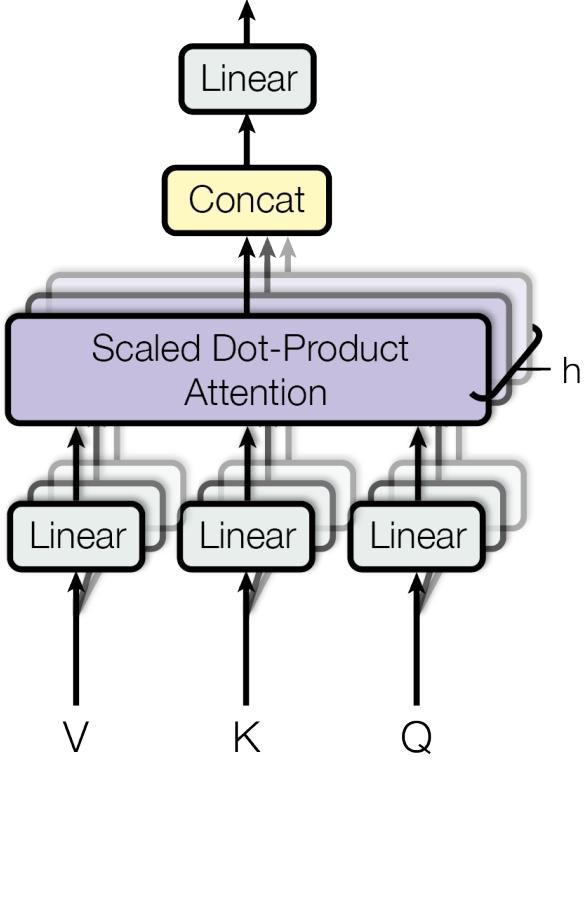

In [26]:
response = chain_with_sources.invoke(
    'What is the Transformer architecture?'
)

print("Responses:", response["response"])

print("\n\nContext:")

for text in response["context"]["texts"]:
    print(text.text)
    print("Page Number:", text.metadata.page_number)
    print("\n" + "-" * 50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)    
